<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

<hr>

**Завдання:** Виконати реалізацію алгоритмів K-середніх та ієрархічної кластеризації на одному з датасетів 
на вибір https://www.kaggle.com/datasets?search=security. Дослідити залежність точності методу від
параметрів даних.

**Теорія:** Алгоритм kNN можна роздiлити на двi простi фази: навчання та класифiкацiї. Пiд час навчання алгоритм просто запам’ятовує вектори ознак спостережень та його мiтки класiв (тобто приклади). Також задається параметр алгоритму k, який задає число «сусiдiв», якi будуть використовуватися пiд час класифiкацiї.

<hr>

### 1. Імпорт бібліотек та алгоритмів

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 2. Завантаження та огляд даних

In [2]:
dataset = pd.read_csv('./malwaremicrosoftbig.csv')  # https://www.kaggle.com/datasets/muhammad4hmed/malwaremicrosoftbig
dataset.shape

(10868, 69)

In [3]:
dataset.sample(5)

,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm,Class
2307,194,214.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,220,...,0.0,0.0,310.0,8.0,0.0,0.0,8.0,146433,8493056,3
4796,562,4033.0,6.0,0.0,0.0,0.0,1161.0,0.0,74.0,5206,...,2.0,43.0,12718.0,1425.0,0.0,2.0,638.0,17153,994816,1
8807,11,164.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,149,...,1.0,0.0,329.0,5.0,3.0,0.0,1.0,91393,5300736,7
7948,196,214.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,227,...,0.0,0.0,327.0,7.0,0.0,1.0,11.0,146433,8493056,3
72,768,313.0,0.0,0.0,0.0,0.0,4.0,0.0,613.0,18455,...,0.0,0.0,805.0,7.0,0.0,1.0,12.0,146433,8493056,3


In [4]:
dataset.describe()

,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm,Class
count,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,...,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,1.086800e+04,10868.000000
mean,724.463839,958.675377,10.774384,200.203165,16.794258,1.900074,480.152742,1.411115,221.034321,16995.688167,...,6.146669,15.102135,2156.040302,330.867777,6.230861,71.709698,493.072874,80667.184026,4.678640e+06,4.017851
std,1568.276158,2891.049563,39.071261,1567.778035,184.439789,35.070993,1384.428550,13.709346,498.249596,32916.498115,...,36.775391,55.051804,6674.654957,1107.955680,17.015893,581.487035,2468.536914,64475.348289,3.739570e+06,2.684621
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1942.000000,1.126280e+05,1.000000
25%,140.000000,178.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,2.000000,217.000000,...,0.000000,0.000000,322.000000,7.000000,0.000000,0.000000,13.000000,15105.000000,8.760320e+05,2.000000
50%,362.000000,261.000000,0.000000,0.000000,1.000000,0.000000,134.500000,0.000000,37.000000,3328.500000,...,1.000000,1.000000,640.000000,50.000000,3.000000,1.000000,81.500000,75364.500000,4.371121e+06,3.000000
75%,766.000000,609.000000,16.000000,2.000000,6.000000,0.000000,401.000000,0.000000,183.000000,18256.000000,...,2.000000,22.000000,1383.000000,188.000000,7.000000,3.000000,273.000000,146433.000000,8.493056e+06,6.000000
max,45684.000000,43479.000000,1384.000000,26600.000000,6830.000000,1540.000000,19617.000000,670.000000,26147.000000,565024.000000,...,1641.000000,1924.000000,130324.000000,25008.000000,515.000000,14725.000000,42457.000000,963585.000000,5.588787e+07,9.000000


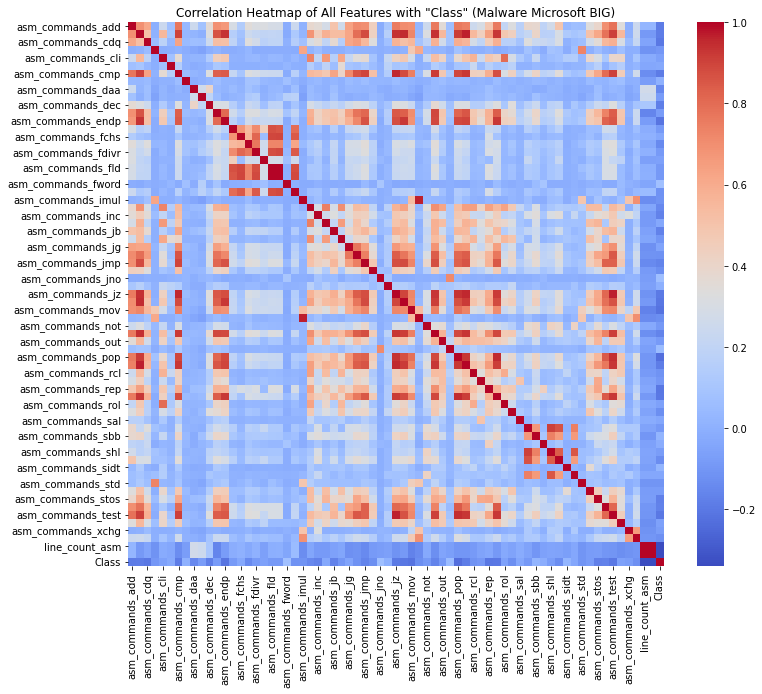

In [5]:
correlation_matrix = dataset.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap of All Features with "Class" (Malware Microsoft BIG)')

plt.show()

In [6]:
# Фільтрація колонок за умовою: |correlation| > 0.2 з "Class"
target_metric = "Class"
correlation_with_target = correlation_matrix[target_metric].abs()
selected_features = correlation_with_target[correlation_with_target > 0.2].index

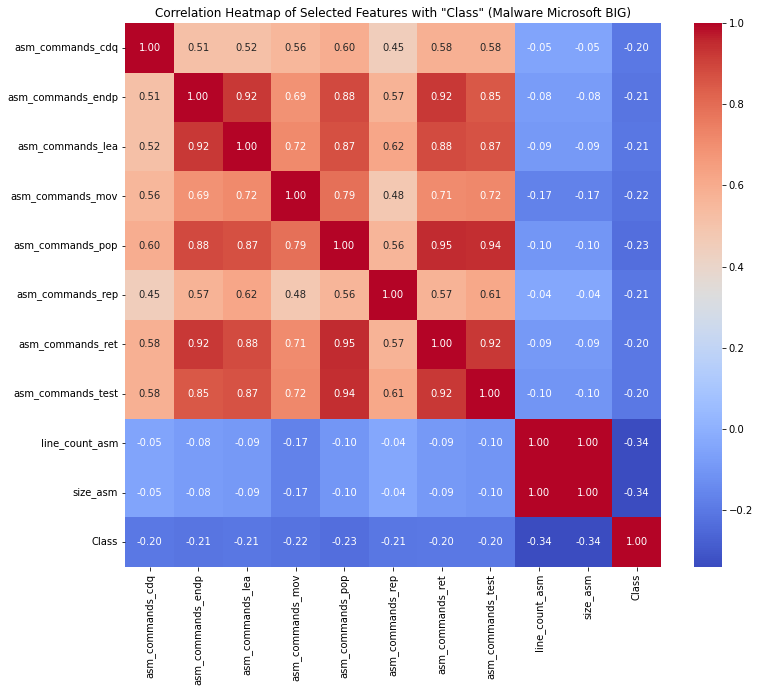

In [7]:
filtered_correlation_matrix = correlation_matrix.loc[selected_features, selected_features]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap of Selected Features with "Class" (Malware Microsoft BIG)')

plt.show()

### 3. Попередня обробка даних¶

* <u>Фільтрація викидів</u>

In [8]:
Q05 = dataset['line_count_asm'].quantile(0.05)
Q95 = dataset['line_count_asm'].quantile(0.95)

filtered_dataset = dataset[(dataset['line_count_asm'] >= Q05) & (dataset['line_count_asm'] <= Q95)]
filtered_dataset.shape

(10429, 69)

* <u>Стандартизація даних</u>

In [9]:
X = filtered_dataset[selected_features]
y = filtered_dataset['Class']

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [10]:
X.quantile(0.95)

asm_commands_cdq           33.0
asm_commands_endp         812.6
asm_commands_lea         1856.6
asm_commands_mov        24811.0
asm_commands_pop         2288.4
asm_commands_rep          109.0
asm_commands_ret         1177.0
asm_commands_test        1575.0
line_count_asm         182017.0
size_asm             10556928.0
Class                       9.0
Name: 0.95, dtype: float64

In [11]:
len(y), len(scaled_X)

(10429, 10429)

* <u>Зменшення розмірності</u>

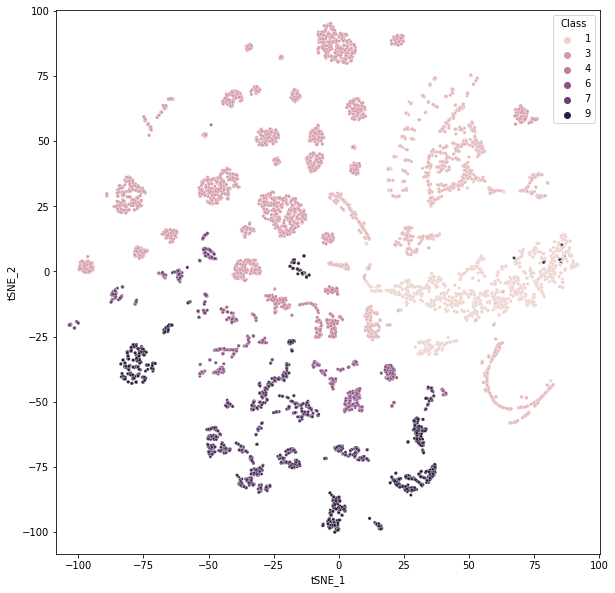

In [12]:
tSNE = TSNE(n_components=2, init='pca', learning_rate='auto')
tSNE_result = tSNE.fit_transform(scaled_X)

tSNE_result_df = pd.DataFrame({'tSNE_1': tSNE_result[:, 0], 'tSNE_2': tSNE_result[:, 1], 'Class': y})

fig, ax = plt.subplots(1, figsize=(10, 10))
sns.scatterplot(x='tSNE_1', y='tSNE_2', hue='Class', data=tSNE_result_df, ax=ax, s=10)
lim = (tSNE_result.min() - 5, tSNE_result.max() + 5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')

* <u>Призначення матриці</u>

In [13]:
X_tSNE = tSNE_result_df.drop(['Class'], axis=1)

X_tSNE.applymap(lambda x: round(x, 2))

,tSNE_1,tSNE_2
0,9.68,18.19
1,-44.30,-68.72
2,-13.89,-0.93
3,-77.11,-32.42
4,19.48,-7.33
...,...,...
10863,-10.48,-12.31
10864,-2.03,-25.10
10865,-21.04,-10.64
10866,-8.45,-23.51


In [14]:
X_tSNE.describe().T

,count,mean,std,min,25%,50%,75%,max
tSNE_1,10429.0,0.819795,45.429707,-103.435921,-31.955391,-0.378078,35.501041,91.817947
tSNE_2,10429.0,-0.084894,45.369881,-100.065483,-34.986427,-0.427446,33.656784,95.289711


### 4. Реалізація кластеризації

#### ◄► **Метод K-середніх**

* <u>Перевірка різних алгоритмів обчислення</u>

In [15]:
silhouette_scores_kmeans = []
algorithms = ["lloyd", "elkan", "auto", "full"]
n_clusters_range = range(2, 11)

for algo in algorithms:
    for n_clusters in n_clusters_range:
        kmeans = KMeans(n_clusters=n_clusters, algorithm=algo, random_state=42)
        cluster_labels = kmeans.fit_predict(X_tSNE)
        
        silhouette_avg = silhouette_score(X_tSNE, cluster_labels)
        silhouette_scores_kmeans.append((algo, n_clusters, silhouette_avg))
        
        print(f"'Algorithm: {algo}' && 'Clusters: {n_clusters}' == 'Silhouette Score: {silhouette_avg:.3f}'")
    print("\n")

'Algorithm: lloyd' && 'Clusters: 2' == 'Silhouette Score: 0.350'
'Algorithm: lloyd' && 'Clusters: 3' == 'Silhouette Score: 0.383'
'Algorithm: lloyd' && 'Clusters: 4' == 'Silhouette Score: 0.380'
'Algorithm: lloyd' && 'Clusters: 5' == 'Silhouette Score: 0.369'
'Algorithm: lloyd' && 'Clusters: 6' == 'Silhouette Score: 0.392'
'Algorithm: lloyd' && 'Clusters: 7' == 'Silhouette Score: 0.390'
'Algorithm: lloyd' && 'Clusters: 8' == 'Silhouette Score: 0.385'
'Algorithm: lloyd' && 'Clusters: 9' == 'Silhouette Score: 0.392'
'Algorithm: lloyd' && 'Clusters: 10' == 'Silhouette Score: 0.394'


'Algorithm: elkan' && 'Clusters: 2' == 'Silhouette Score: 0.350'
'Algorithm: elkan' && 'Clusters: 3' == 'Silhouette Score: 0.383'
'Algorithm: elkan' && 'Clusters: 4' == 'Silhouette Score: 0.380'
'Algorithm: elkan' && 'Clusters: 5' == 'Silhouette Score: 0.369'
'Algorithm: elkan' && 'Clusters: 6' == 'Silhouette Score: 0.392'
'Algorithm: elkan' && 'Clusters: 7' == 'Silhouette Score: 0.390'
'Algorithm: elkan' && 

* <u>Оцінка точності методу за силуетом</u>

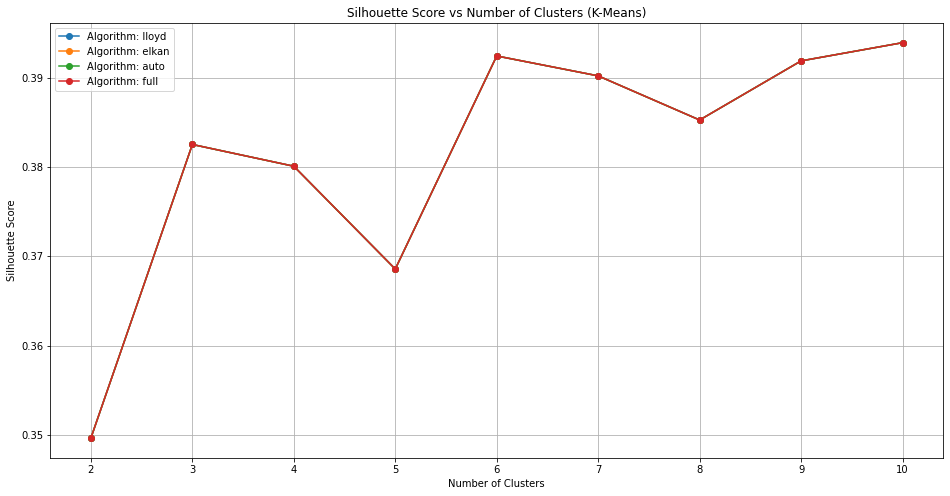

In [16]:
plt.figure(figsize=(16, 8))

for algo in algorithms:
    scores = [score[2] for score in silhouette_scores_kmeans if score[0] == algo]
    plt.plot(n_clusters_range, scores, marker='o', label=f'Algorithm: {algo}')
plt.title('Silhouette Score vs Number of Clusters (K-Means)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.legend()

plt.show()

#### ◄► **Ієрархічна кластеризація**

* <u>Перевірка різних метрик відстані</u>

In [17]:
silhouette_scores_hc = []
linkage_methods = ['ward', 'complete', 'average']
n_clusters_list = range(2, 11)

for method in linkage_methods:
    for n in n_clusters_list:
        clustering = AgglomerativeClustering(n_clusters=n, linkage=method)
        cluster_labels = clustering.fit_predict(X_tSNE)
        
        silhouette_avg = silhouette_score(X_tSNE, cluster_labels)
        silhouette_scores_hc.append((method, n, silhouette_avg))
        
        print(f"'Method: {method}' && 'Clusters: {n}' == 'Silhouette Score: {silhouette_avg:.3f}'")
    print("\n")

'Method: ward' && 'Clusters: 2' == 'Silhouette Score: 0.293'
'Method: ward' && 'Clusters: 3' == 'Silhouette Score: 0.299'
'Method: ward' && 'Clusters: 4' == 'Silhouette Score: 0.286'
'Method: ward' && 'Clusters: 5' == 'Silhouette Score: 0.295'
'Method: ward' && 'Clusters: 6' == 'Silhouette Score: 0.338'
'Method: ward' && 'Clusters: 7' == 'Silhouette Score: 0.353'
'Method: ward' && 'Clusters: 8' == 'Silhouette Score: 0.356'
'Method: ward' && 'Clusters: 9' == 'Silhouette Score: 0.352'
'Method: ward' && 'Clusters: 10' == 'Silhouette Score: 0.345'


'Method: complete' && 'Clusters: 2' == 'Silhouette Score: 0.290'
'Method: complete' && 'Clusters: 3' == 'Silhouette Score: 0.346'
'Method: complete' && 'Clusters: 4' == 'Silhouette Score: 0.348'
'Method: complete' && 'Clusters: 5' == 'Silhouette Score: 0.317'
'Method: complete' && 'Clusters: 6' == 'Silhouette Score: 0.324'
'Method: complete' && 'Clusters: 7' == 'Silhouette Score: 0.310'
'Method: complete' && 'Clusters: 8' == 'Silhouette Score: 

* <u>Оцінка точності методу за силуетом</u>

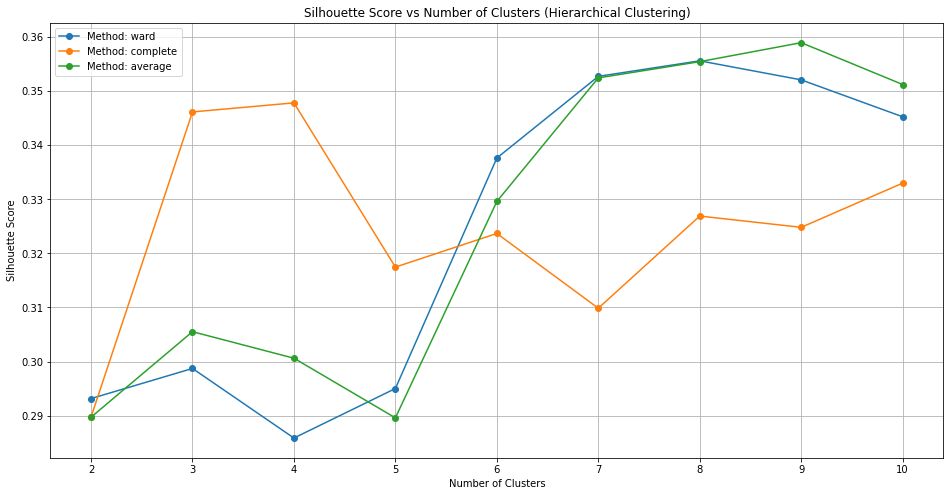

In [18]:
plt.figure(figsize=(16, 8))

for method in linkage_methods:
    scores = [score[2] for score in silhouette_scores_hc if score[0] == method]
    plt.plot(n_clusters_list, scores, marker='o', label=f'Method: {method}')
plt.title('Silhouette Score vs Number of Clusters (Hierarchical Clustering)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.legend()

plt.show()

### 5. Побудова візуалізацій кластерів

#### ◄► **Метод K-середніх**

In [19]:
def kmeans_clustering(X_tSNE, n_clusters):
    model_cluster = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = model_cluster.fit_predict(X_tSNE)
    
    silhouette_avg = silhouette_score(X_tSNE, cluster_labels)
    
    print(f"☼ K-Means Clustering with {n_clusters} clusters: Silhouette Score = {silhouette_avg:.3f}")
    return model_cluster, cluster_labels

In [20]:
model_kmeans, kmeans_labels = kmeans_clustering(X_tSNE, 6)

cluster_centers = model_kmeans.cluster_centers_

☼ K-Means Clustering with 6 clusters: Silhouette Score = 0.392


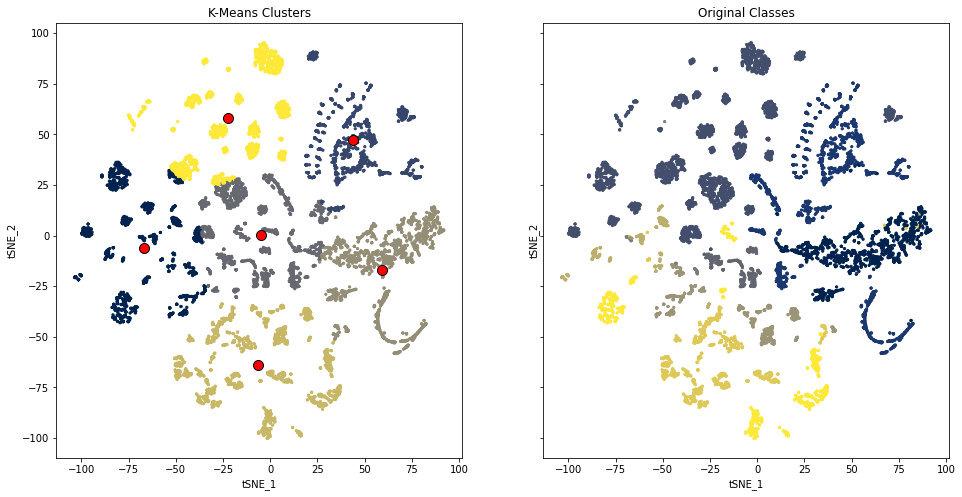

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

ax1.set_title('K-Means Clusters')
ax1.scatter(X_tSNE['tSNE_1'], X_tSNE['tSNE_2'], c=kmeans_labels, cmap='cividis', s=5)
ax1.scatter(cluster_centers[:, 0], cluster_centers[:, 1], color='red', s=100, edgecolor='black')
ax1.set_xlabel('tSNE_1')
ax1.set_ylabel('tSNE_2')

ax2.set_title('Original Classes')
ax2.scatter(X_tSNE['tSNE_1'], X_tSNE['tSNE_2'], c=y, cmap='cividis', s=5)
ax2.set_xlabel('tSNE_1')
ax2.set_ylabel('tSNE_2')

plt.show()

#### ◄► **Ієрархічна кластеризація**

In [22]:
def hierarchical_clustering(X_tSNE, n_clusters):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = agg_clustering.fit_predict(X_tSNE)
    
    silhouette_avg = silhouette_score(X_tSNE, cluster_labels)
    
    print(f"☼ Hierarchical Clustering with {n_clusters} clusters: Silhouette Score = {silhouette_avg:.3f}")
    return cluster_labels

In [23]:
hierarchical_labels = hierarchical_clustering(X_tSNE, 6)

# Обчислення центроїдів для кожного кластера
centroids = []
for i in range(6):
    cluster_points = X_tSNE[hierarchical_labels == i]
    centroids.append(cluster_points.mean(axis=0))

centroids = np.array(centroids)

☼ Hierarchical Clustering with 6 clusters: Silhouette Score = 0.338


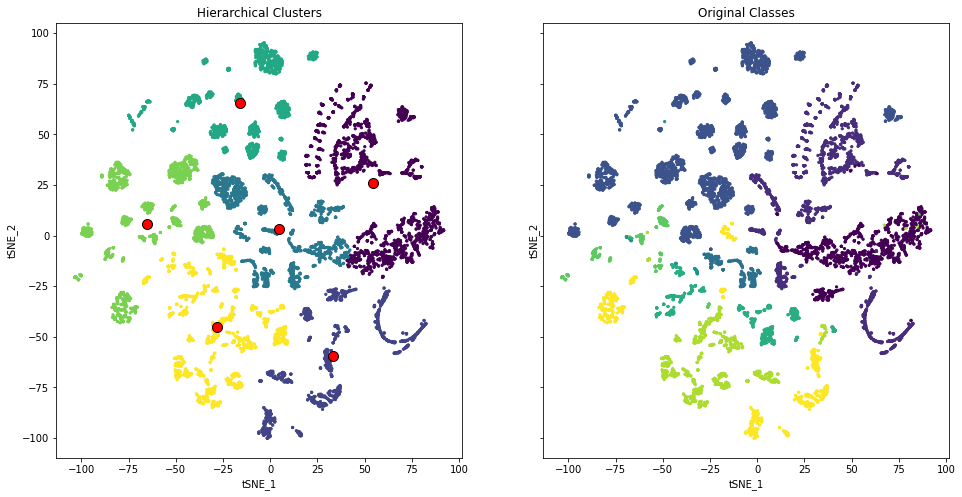

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

ax1.set_title('Hierarchical Clusters')
ax1.scatter(X_tSNE['tSNE_1'], X_tSNE['tSNE_2'], c=hierarchical_labels, cmap='viridis', s=5)
ax1.scatter(centroids[:, 0], centroids[:, 1], marker='o', color='red', s=100, edgecolor='black')
ax1.set_xlabel('tSNE_1')
ax1.set_ylabel('tSNE_2')

ax2.set_title('Original Classes')
ax2.scatter(X_tSNE['tSNE_1'], X_tSNE['tSNE_2'], c=y, cmap='viridis', s=5)
ax2.set_xlabel('tSNE_1')
ax2.set_ylabel('tSNE_2')

plt.show()

<hr>

### * Загальні характеристики алгоритмів

#### ◄► **Метод K-середніх**

**Переваги**

•	<u>Простота</u>: Алгоритм легко зрозуміти та реалізувати, забезпечуючи швидку обробку даних навіть у великих наборах; 

•	<u>Швидкість</u>: K-Means ефективний за обчислювальною складністю 𝑂(𝑛𝑘𝑑𝑖), де 𝑛 — точки, 𝑘 — кластери, 𝑑 — виміри, 𝑖 — ітерації;

•	<u>Гнучкість</u>: Може адаптуватися до різних розмірів та форм кластерів за рахунок налаштування параметра 𝑘.

**Недолiки** 

•	<u>Чутливість до початкових умов</u>: Неправильна ініціалізація може призводити до локальних мінімумів;

•	<u>Обмеження форми кластерів</u>: Підходить лише для сферичних або ізотропних кластерів;

•	<u>Необхідність задавати 𝑘</u>: Параметр кількості кластерів повинен бути визначений заздалегідь.

<u>**Застосування**<u>

Алгоритм K-Means широко застосовується в задачах аналізу зображень, таких як кластеризація пікселів для сегментації об'єктів, оптимізація кольорових палітр для зменшення розміру файлів, аналіз та сегментація клієнтів у маркетингових дослідженнях, а також виявлення аномалій у великих наборах даних, включаючи моніторинг кібербезпеки та інфраструктурних систем.

[URL] https://scikit-learn.org/1.5/modules/clustering.html#k-means

#### ◄► **Ієрархічна кластеризація**

**Переваги**

•	<u>Не потрібно задавати 𝑘</u>: На відміну від K-Means, ієрархічна кластеризація автоматично визначає структуру; 

•	<u>Гнучкість метрик</u>: Можливість використання різних метрик вимірювання відстані;

•	<u>Візуалізація</u>: Дендрограми дозволяють зручно досліджувати візуальну структуру даних.

**Недолiки** 

•	<u>Масштабованість</u>: Обчислювальна складність $𝑂(𝑛^3)$ обмежує застосування для великих наборів даних;

•	<u>Чутливість до шуму</u>: Алгоритм може некоректно об'єднувати точки через аномалії в даних;

•	<u>Високе використання пам'яті</u>: Потрібна велика кількість пам'яті для збереження всіх проміжних розрахунків.

<u>**Застосування**<u>

Ієрархічна кластеризація застосовується в біоінформатиці для аналізу ДНК-послідовностей, у текстовій аналітиці для кластеризації документів, а також у соціологічних дослідженнях для групування учасників за поведінкою, часто допомагаючи візуалізувати природну структуру даних у вигляді дендрограм, що особливо корисно для складних та малих наборів даних.

[URL] https://scikit-learn.org/1.5/modules/clustering.html#hierarchical-clustering